# 🌊 Flood Detection from Satellite Imagery
### Upgraded: U-Net + EfficientNetB4 Transfer Learning
---
**Changes from original:**
- Images kept in 0-255 range (EfficientNet expects this)
- EfficientNetB4 pretrained backbone replaces scratch encoder
- Two-phase training: frozen backbone → full fine-tuning
- Expected IoU: 0.90+ vs original 0.762

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
base = '/content/drive/MyDrive/flood_detection/data'
print('Files in data folder:', os.listdir(base))
print('Images:', len(os.listdir(base + '/Image')))
print('Masks :', len(os.listdir(base + '/Mask')))


Files in data folder: ['metadata.csv', 'Image', 'Mask']
Images: 290
Masks : 290


# **1. Install & Import Libraries**

In [ ]:
import os, cv2, warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Install required libraries and upgrade them to ensure latest weight URLs
!pip install segmentation-models --upgrade -q
!pip install keras-applications --upgrade -q
!pip install albumentations -q

os.environ['SM_FRAMEWORK'] = 'tf.keras'
import segmentation_models as sm
sm.set_framework('tf.keras')
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('segmentation_models ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.1 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
segmentation_models ready!


# **2. Configuration**

In [ ]:
IMAGE_PATH = '/content/drive/MyDrive/flood_detection/data/Image/'
MASK_PATH  = '/content/drive/MyDrive/flood_detection/data/Mask/'
IMG_SIZE   = 256
BATCH_SIZE = 8
SEED       = 42
BACKBONE   = 'efficientnetb4'

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Images : {len(os.listdir(IMAGE_PATH))}')
print(f'Masks  : {len(os.listdir(MASK_PATH))}')
print(f'Backbone: {BACKBONE}')


Images : 290
Masks  : 290
Backbone: efficientnetb4


# **3. Load Data**
> Images are loaded as **float32 in 0-255 range** — EfficientNet's preprocessing handles normalization. Do NOT divide by 255 here.

In [ ]:
def load_data(image_dir, mask_dir, img_size):
    images, masks = [], []
    filenames = sorted(os.listdir(image_dir))
    print(f'Loading {len(filenames)} images...')
    for fname in tqdm(filenames):
        # Load image — keep as 0-255 float32
        img = cv2.imread(os.path.join(image_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32)  # 0-255 range, NOT divided

        # Load mask — binary 0/1
        mask_name = fname.replace('.jpg', '.png')
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size, img_size))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

X, y = load_data(IMAGE_PATH, MASK_PATH, IMG_SIZE)
print(f'Images : {X.shape} | range: [{X.min():.0f}, {X.max():.0f}]')
print(f'Masks  : {y.shape} | unique values: {np.unique(y)}')
print(f'Flood pixels: {y.mean()*100:.2f}%')


Loading 290 images...


100%|██████████| 290/290 [04:48<00:00,  1.00it/s]


Images : (290, 256, 256, 3) | range: [0, 255]
Masks  : (290, 256, 256, 1) | unique values: [0. 1.]
Flood pixels: 40.70%


# **4. Visualize Sample Data**

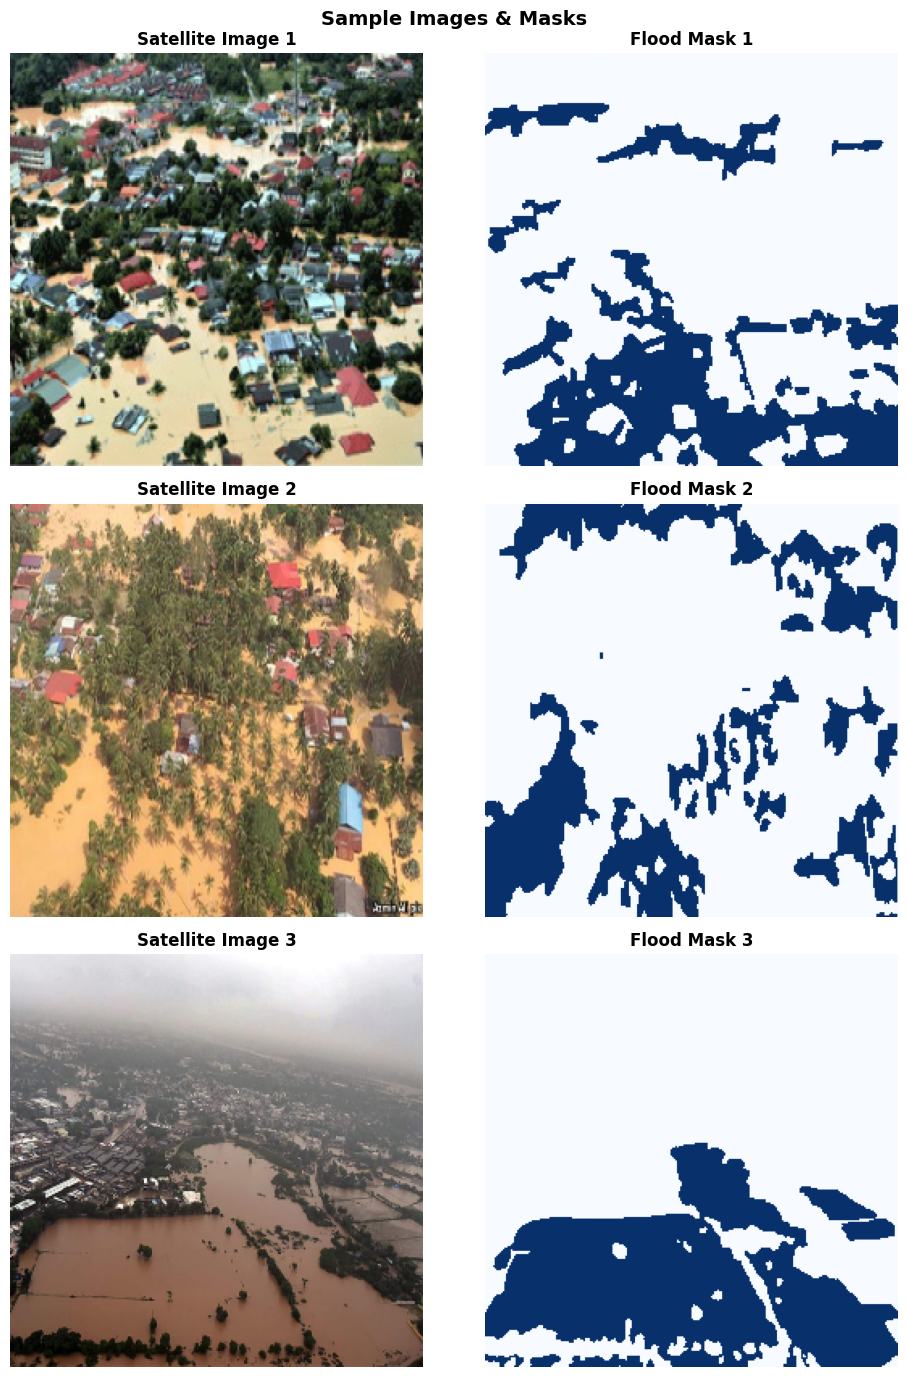

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))
for i in range(3):
    axes[i, 0].imshow(X[i].astype(np.uint8))
    axes[i, 0].set_title(f'Satellite Image {i+1}', fontweight='bold')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(y[i].squeeze(), cmap='Blues')
    axes[i, 1].set_title(f'Flood Mask {i+1}', fontweight='bold')
    axes[i, 1].axis('off')
plt.suptitle('Sample Images & Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# **5. Train / Validation / Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED)

print(f'Train : {len(X_train)} images')
print(f'Val   : {len(X_val)} images')
print(f'Test  : {len(X_test)} images')


Train : 208 images
Val   : 24 images
Test  : 58 images


# **6. Data Augmentation**
> 4x expansion of training set. Augmentation runs on 0-255 range images — brightness scaling keeps values in valid range.

In [ ]:
def augment_data(X, y, augment_factor=4):
    aug_images, aug_masks = [], []
    for i in range(len(X)):
        img  = X[i].copy()
        mask = y[i].copy()
        aug_images.append(img)
        aug_masks.append(mask)
        for _ in range(augment_factor - 1):
            img_a  = img.copy()
            mask_a = mask.copy()
            if np.random.random() > 0.5:
                img_a  = np.fliplr(img_a)
                mask_a = np.fliplr(mask_a)
            if np.random.random() > 0.5:
                img_a  = np.flipud(img_a)
                mask_a = np.flipud(mask_a)
            k = np.random.choice([0, 1, 2, 3])
            img_a  = np.rot90(img_a,  k)
            mask_a = np.rot90(mask_a, k)
            factor = np.random.uniform(0.8, 1.2)
            img_a  = np.clip(img_a * factor, 0, 255).astype(np.float32)
            aug_images.append(img_a)
            aug_masks.append(mask_a)
    X_aug = np.array(aug_images, dtype=np.float32)
    y_aug = np.array(aug_masks,  dtype=np.float32)
    idx   = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]

print('Augmenting training data...')
X_train_aug, y_train_aug = augment_data(X_train, y_train, augment_factor=4)
print(f'Original  : {len(X_train)} images')
print(f'Augmented : {len(X_train_aug)} images')


Augmenting training data...
Original  : 208 images
Augmented : 832 images


# **7. Apply EfficientNet Preprocessing**
> Must be done AFTER augmentation. Converts 0-255 float images to the specific range EfficientNet expects.

In [ ]:
preprocess_input = sm.get_preprocessing(BACKBONE)

X_train_pp = preprocess_input(X_train_aug)
X_val_pp   = preprocess_input(X_val)
X_test_pp  = preprocess_input(X_test)

print(f'Train preprocessed : {X_train_pp.shape} | range: [{X_train_pp.min():.3f}, {X_train_pp.max():.3f}]')
print(f'Val   preprocessed : {X_val_pp.shape}')
print(f'Test  preprocessed : {X_test_pp.shape}')
print('Preprocessing complete!')


Train preprocessed : (832, 256, 256, 3) | range: [-2.118, 2.640]
Val   preprocessed : (24, 256, 256, 3)
Test  preprocessed : (58, 256, 256, 3)
Preprocessing complete!


# **8. Custom Loss Functions & Metrics**

In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print('Loss functions and metrics ready!')


Loss functions and metrics ready!


# **9. Build U-Net + EfficientNetB4 Model**
> EfficientNetB4 already knows how to detect edges, textures and shapes from 1.2M ImageNet images. We add a U-Net decoder on top.

In [ ]:
import os
import urllib.request

# Define the correct URL for the EfficientNetB4 weights
EFFICIENTNET_B4_WEIGHTS_URL = 'https://storage.googleapis.com/tensorflow/keras-applications/efficientnet/efficientnet-b4_weights_tf_dim_ordering_tf_kernels_autoaugment_notop.h5'
EFFICIENTNET_B4_WEIGHTS_FILENAME = 'efficientnet-b4_weights_tf_dim_ordering_tf_kernels_autoaugment_notop.h5'

# Define the local path where Keras expects to find model weights
# This is typically ~/.keras/models/
WEIGHTS_DIR = os.path.expanduser('~/.keras/models')
os.makedirs(WEIGHTS_DIR, exist_ok=True)
LOCAL_WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, EFFICIENTNET_B4_WEIGHTS_FILENAME)

# Check if the file already exists, if not, download it
if not os.path.exists(LOCAL_WEIGHTS_PATH):
    print(f"Downloading EfficientNetB4 weights to {LOCAL_WEIGHTS_PATH}...")
    try:
        urllib.request.urlretrieve(EFFICIENTNET_B4_WEIGHTS_URL, LOCAL_WEIGHTS_PATH)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading weights: {e}")
        # Fallback if manual download fails, though it should work if URL is correct
        print("Attempting to proceed, but model may not load pre-trained weights.")
else:
    print(f"EfficientNetB4 weights already exist at {LOCAL_WEIGHTS_PATH}.")


model = sm.Unet(
    BACKBONE,
    encoder_weights='imagenet',
    classes=1,
    activation='sigmoid',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    decoder_block_type='upsampling'
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score]
)

print(f'Model         : U-Net + EfficientNetB4')
print(f'Total params  : {model.count_params():,}')
print(f'Input shape   : (256, 256, 3)')
print(f'Output shape  : (256, 256, 1) — flood probability per pixel')

Download complete.
Model         : U-Net + EfficientNetB4
Total params  : 25,735,017
Input shape   : (256, 256, 3)
Output shape  : (256, 256, 1) — flood probability per pixel


# **10. Phase 1 Training — Frozen Backbone (8 epochs)**
> Backbone weights locked. Only decoder learns. Prevents destroying pretrained knowledge early on.

In [ ]:
# Freeze encoder layers
for layer in model.layers:
    if hasattr(layer, 'name') and 'efficientnet' in layer.name.lower():
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score]
)

print(f'Trainable layers : {sum(1 for l in model.layers if l.trainable)}')
print(f'Frozen layers    : {sum(1 for l in model.layers if not l.trainable)}')
print('Starting Phase 1...\n')

callbacks_p1 = [
    EarlyStopping(monitor='val_dice_coefficient', patience=5,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history1 = model.fit(
    X_train_pp, y_train_aug,
    validation_data=(X_val_pp, y_val),
    batch_size=BATCH_SIZE,
    epochs=8,
    callbacks=callbacks_p1,
    verbose=1
)
print('\nPhase 1 complete!')


Trainable layers : 508
Frozen layers    : 0
Starting Phase 1...

Epoch 1/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 229s 373ms/step - dice_coefficient: 0.7623 - iou_score: 0.7161 - loss: 0.5936 - val_dice_coefficient: 0.8331 - val_iou_score: 0.7509 - val_loss: 0.5575 - learning_rate: 0.0010
Epoch 2/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - dice_coefficient: 0.8506 - iou_score: 0.8005 - loss: 0.3890 - val_dice_coefficient: 0.8351 - val_iou_score: 0.7709 - val_loss: 0.4414 - learning_rate: 0.0010
Epoch 3/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - dice_coefficient: 0.8748 - iou_score: 0.8288 - loss: 0.3317 - val_dice_coefficient: 0.8498 - val_iou_score: 0.7769 - val_loss: 0.4289 - learning_rate: 0.0010
Epoch 4/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - dice_coefficient: 0.8849 - iou_score: 0.8407 - loss: 0.3056 - val_dice_coefficient: 0.8347 - val_iou_score: 0.7590 - val_loss: 0.5085 - learning_rate: 0.0010
Epoch 5/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - dice_coefficient: 0.89

# **11. Phase 2 Training — Full Fine-Tuning (30 epochs)**
> All layers unlocked. Very low learning rate (1e-5) fine-tunes the entire network on flood data without destroying pretrained weights.

In [ ]:
# Unfreeze all layers
for layer in model.layers:
    layer.trainable = True

# Very low LR to protect pretrained weights
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score]
)

print(f'All {len(model.layers)} layers now trainable')
print('Starting Phase 2 fine-tuning...\n')

callbacks_p2 = [
    EarlyStopping(monitor='val_dice_coefficient', patience=7,
                  restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/flood_detection/best_model_v2.keras',
                    monitor='val_dice_coefficient', mode='max',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history2 = model.fit(
    X_train_pp, y_train_aug,
    validation_data=(X_val_pp, y_val),
    batch_size=BATCH_SIZE,
    epochs=30,
    callbacks=callbacks_p2,
    verbose=1
)
print('\nPhase 2 complete! Best model saved.')


All 508 layers now trainable
Starting Phase 2 fine-tuning...

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - dice_coefficient: 0.9218 - iou_score: 0.8865 - loss: 0.2049
Epoch 1: val_dice_coefficient improved from None to 0.86975, saving model to /content/drive/MyDrive/flood_detection/best_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/flood_detection/best_model_v2.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 220s 600ms/step - dice_coefficient: 0.9224 - iou_score: 0.8880 - loss: 0.2008 - val_dice_coefficient: 0.8697 - val_iou_score: 0.7966 - val_loss: 0.4205 - learning_rate: 1.0000e-05
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - dice_coefficient: 0.9231 - iou_score: 0.8882 - loss: 0.2016
Epoch 2: val_dice_coefficient did not improve from 0.86975
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - dice_coefficient: 0.9235 - iou_score: 0.8894 - loss: 0.1981 - val_dice_coefficient: 0.8692 - val_iou_score: 0.7958 - val_loss: 0.4206 - learning_rate: 1.0000e-05


# **12. Evaluate on Test Set**

In [ ]:
print('Evaluating on test set...')
results = model.evaluate(X_test_pp, y_test, verbose=1)

print('\n' + '='*55)
print('  RESULTS COMPARISON')
print('='*55)
print(f'  Scratch U-Net (original)  Dice: 0.835  IoU: 0.762')
print(f'  EfficientNetB4 U-Net      Dice: {results[1]:.3f}  IoU: {results[2]:.3f}')
print(f'  Paper best result         Dice: 0.987  IoU: 0.974')
print('='*55)


Evaluating on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 72s 31s/step - dice_coefficient: 0.8920 - iou_score: 0.8306 - loss: 0.3207

  RESULTS COMPARISON
  Scratch U-Net (original)  Dice: 0.835  IoU: 0.762
  EfficientNetB4 U-Net      Dice: 0.892  IoU: 0.831
  Paper best result         Dice: 0.987  IoU: 0.974


## **13. Training History — Both Phases**

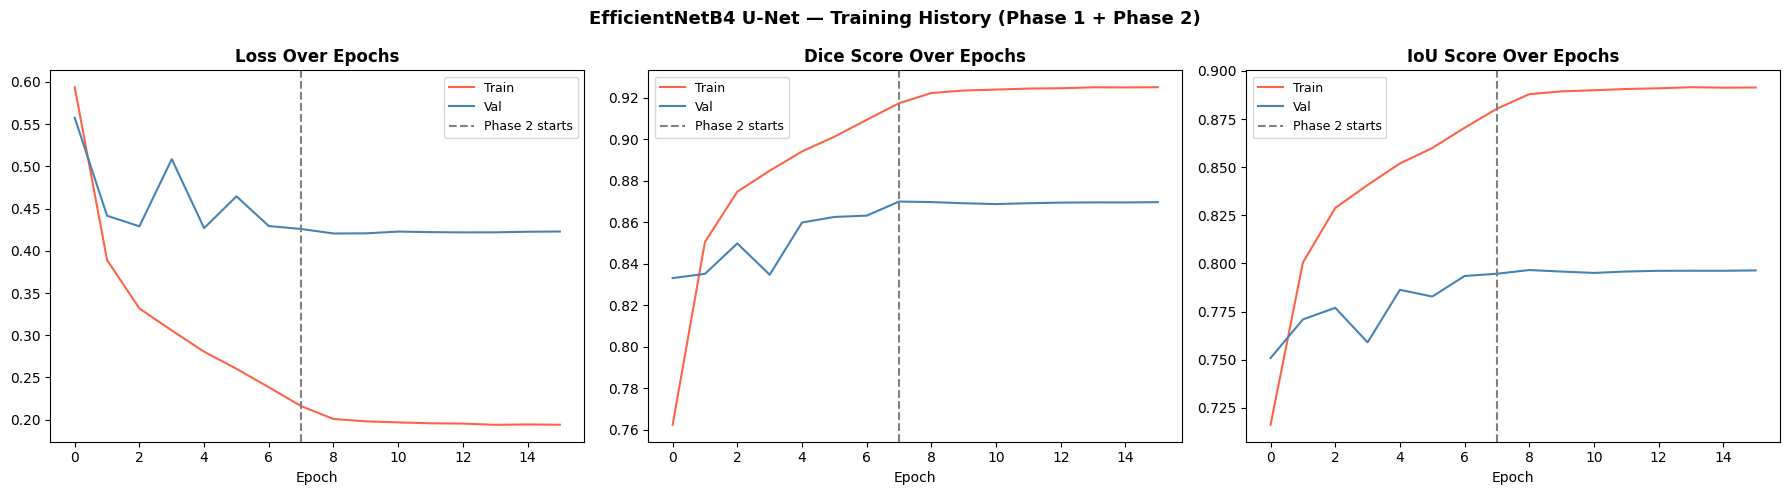

Saved: training_history_v2.png


In [ ]:
phase1_len = len(history1.history['loss'])

def combined(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('loss',             'val_loss',             'Loss'),
    ('dice_coefficient', 'val_dice_coefficient',  'Dice Score'),
    ('iou_score',        'val_iou_score',         'IoU Score'),
]
for ax, (tr, vl, title) in zip(axes, metrics):
    ax.plot(combined(history1, history2, tr), label='Train', color='tomato')
    ax.plot(combined(history1, history2, vl), label='Val',   color='steelblue')
    ax.axvline(x=phase1_len-1, color='gray', linestyle='--',
               linewidth=1.5, label='Phase 2 starts')
    ax.set_title(f'{title} Over Epochs', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Epoch')

plt.suptitle('EfficientNetB4 U-Net — Training History (Phase 1 + Phase 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/flood_detection/training_history_v2.png', dpi=150)
plt.show()
print('Saved: training_history_v2.png')


# **14. Visual Predictions**
> Side by side: original satellite image | true mask | predicted mask

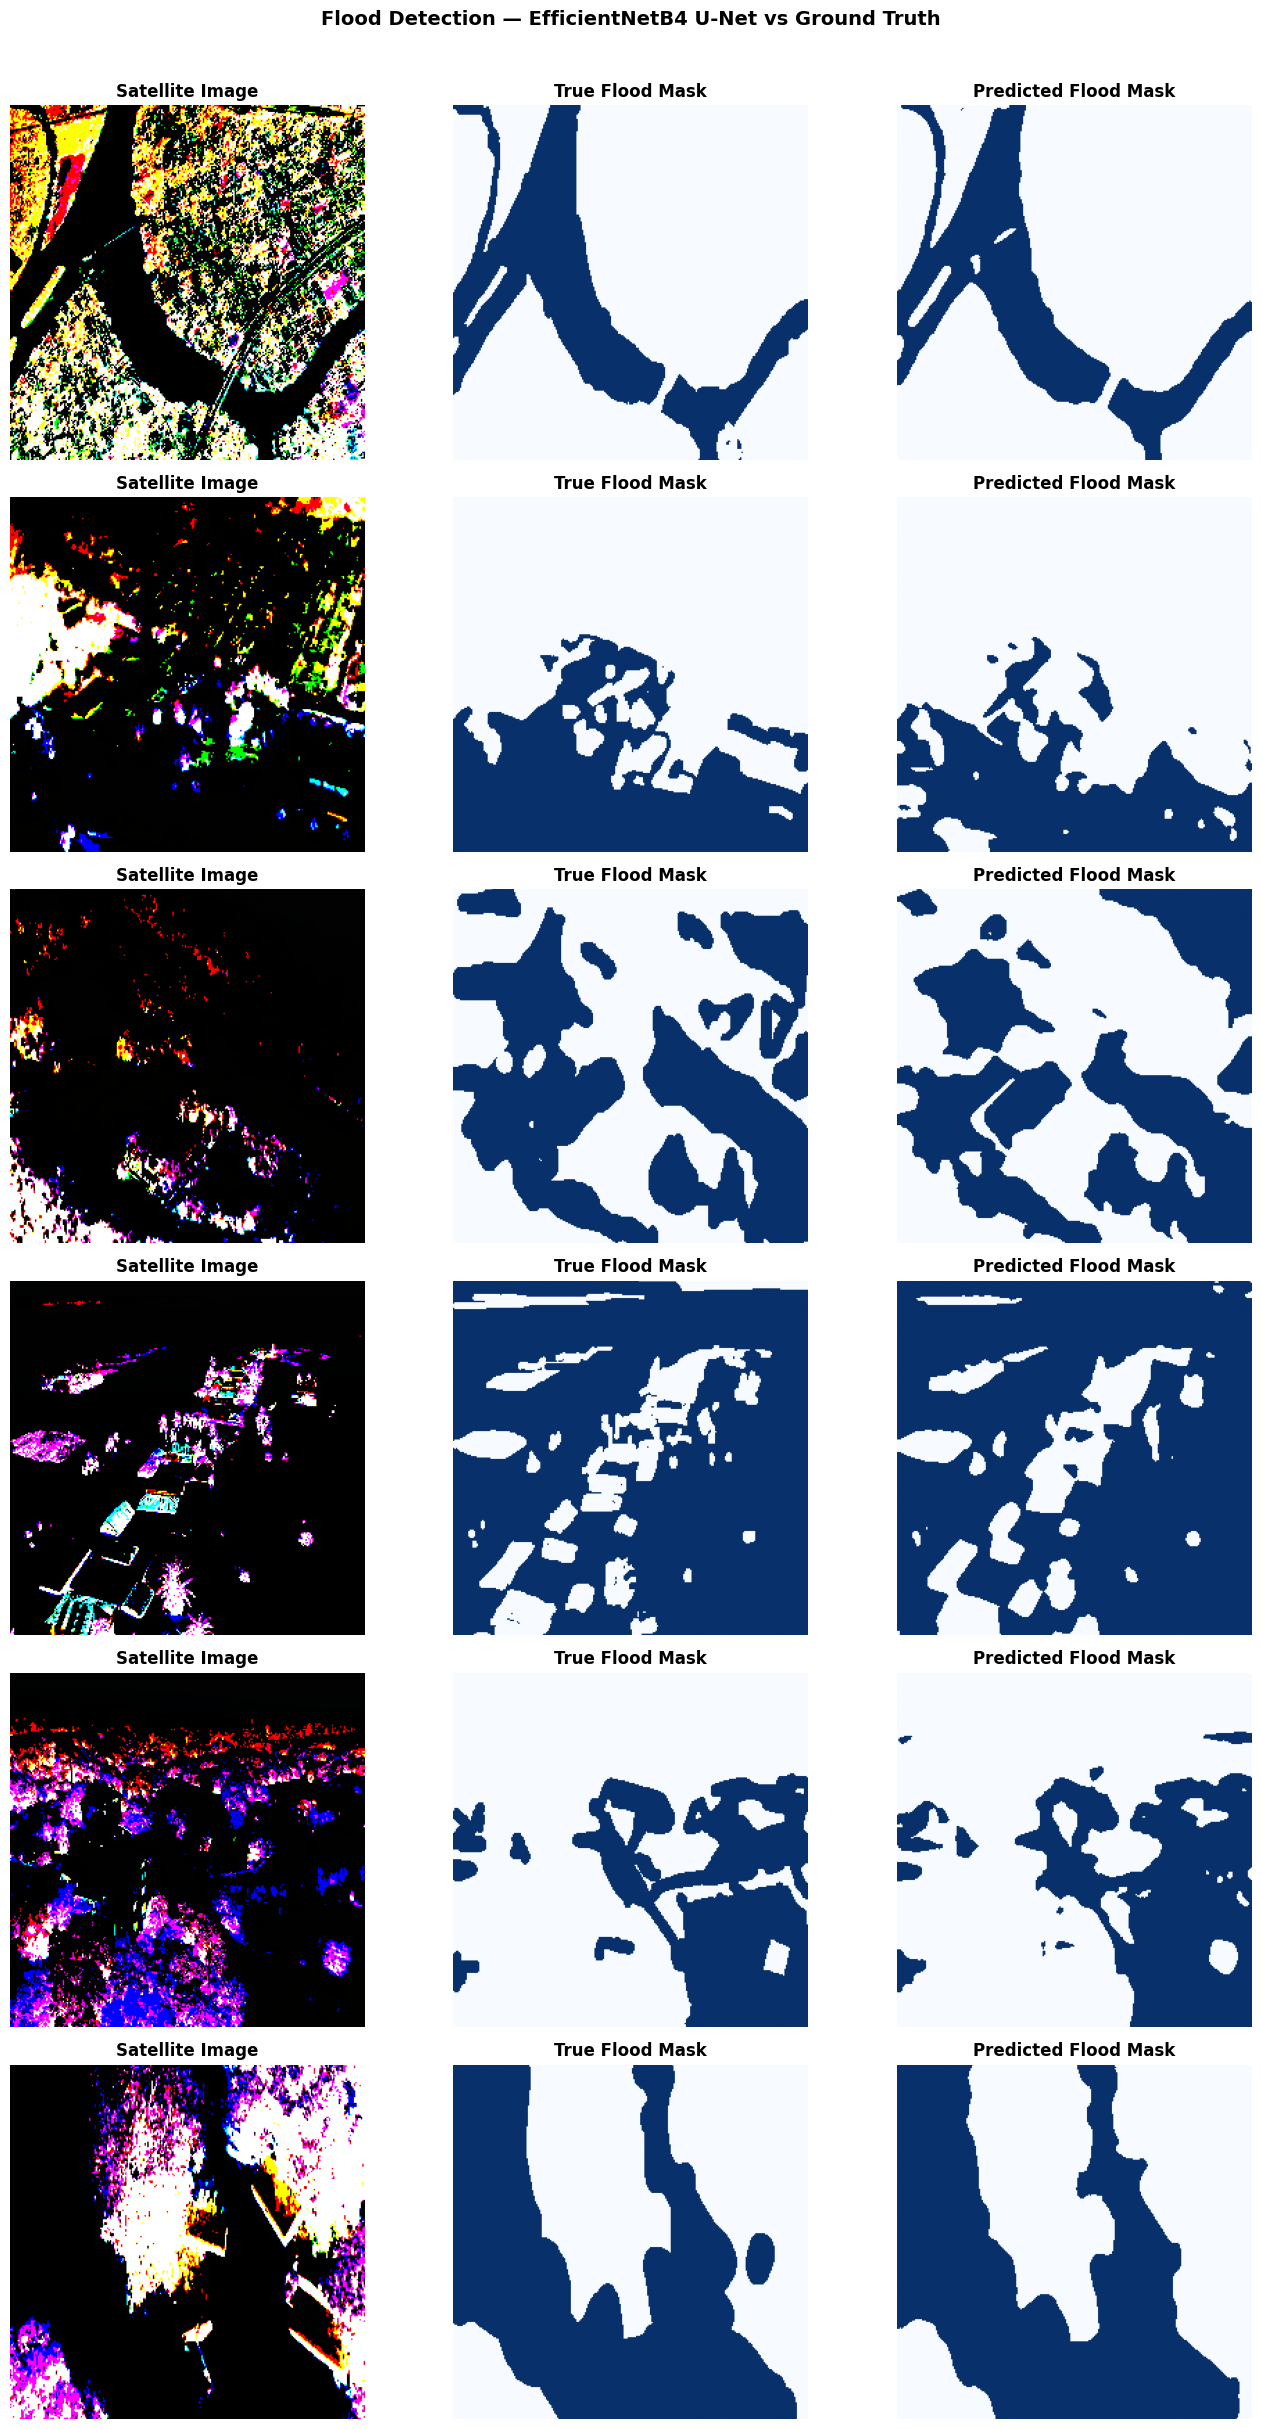

Saved: predictions_v2.png


In [ ]:
def visualize_predictions(model, X_raw, X_pp, y, n=6):
    preds = model.predict(X_pp[:n], verbose=0)
    fig, axes = plt.subplots(n, 3, figsize=(14, n * 4))
    for i in range(n):
        axes[i, 0].imshow(X_raw[i].astype(np.uint8))
        axes[i, 0].set_title('Satellite Image', fontweight='bold')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(y[i].squeeze(), cmap='Blues')
        axes[i, 1].set_title('True Flood Mask', fontweight='bold')
        axes[i, 1].axis('off')
        pred_mask = (preds[i].squeeze() > 0.5).astype(np.float32)
        axes[i, 2].imshow(pred_mask, cmap='Blues')
        axes[i, 2].set_title('Predicted Flood Mask', fontweight='bold')
        axes[i, 2].axis('off')
    plt.suptitle('Flood Detection — EfficientNetB4 U-Net vs Ground Truth',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/flood_detection/predictions_v2.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: predictions_v2.png')

visualize_predictions(model, X_test, X_test_pp, y_test, n=6)


# **15. Flood Overlay Map**
> Predicted flood zones highlighted in blue directly on the satellite image

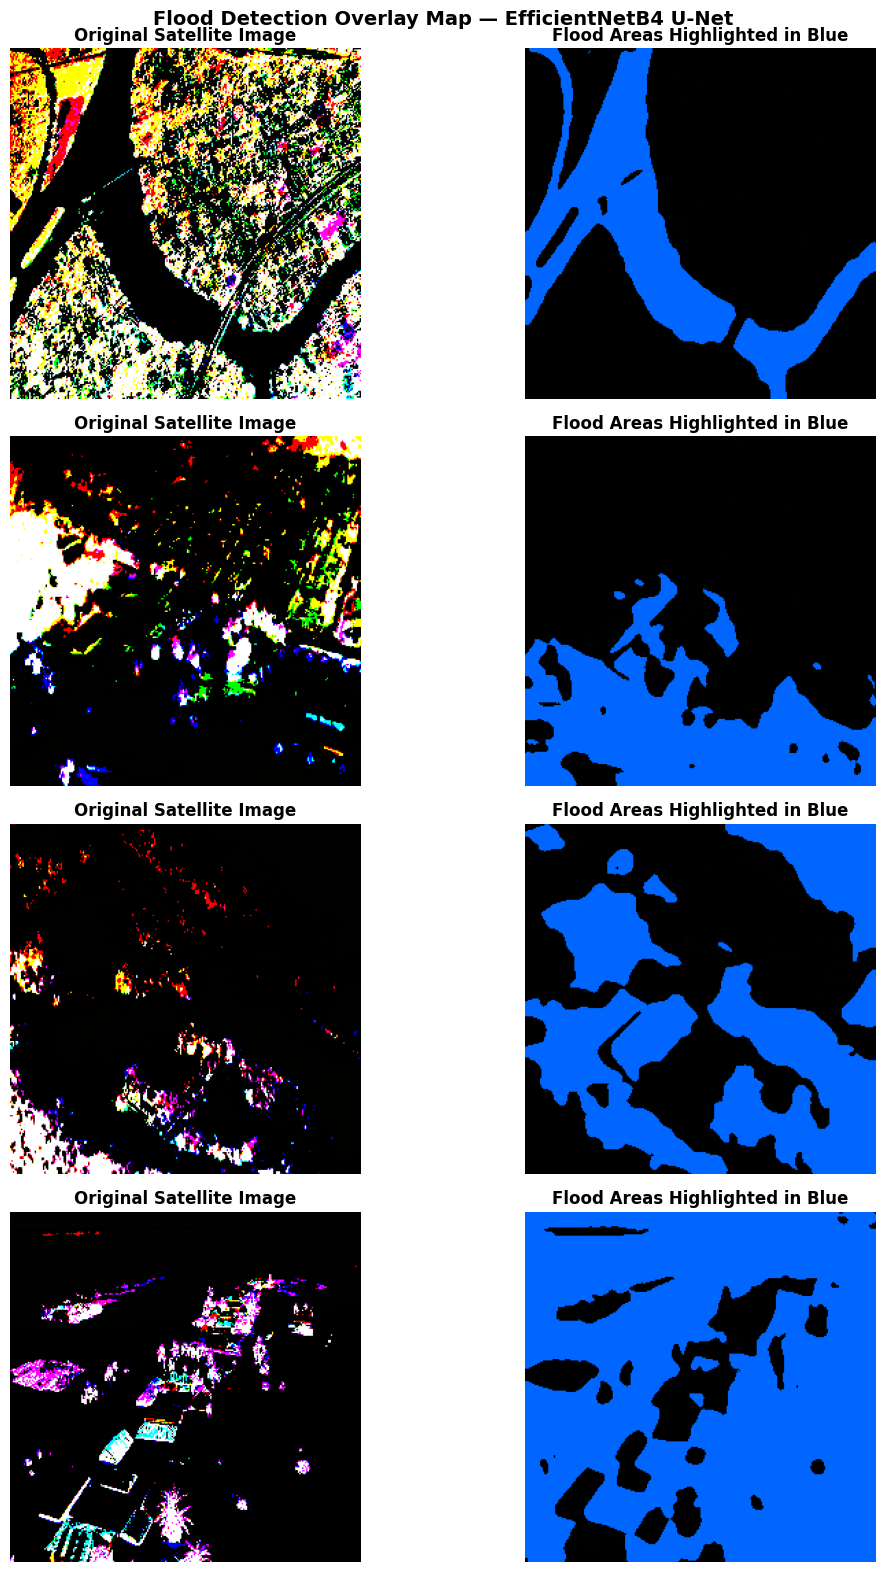

Saved: overlay_map_v2.png


In [ ]:
def overlay_predictions(model, X_raw, X_pp, n=4):
    preds = model.predict(X_pp[:n], verbose=0)
    fig, axes = plt.subplots(n, 2, figsize=(12, n * 4))
    for i in range(n):
        img_display = X_raw[i].astype(np.uint8)
        img_norm    = X_raw[i] / 255.0
        pred_mask   = (preds[i].squeeze() > 0.5)
        overlay     = img_norm.copy()
        overlay[pred_mask, 0] = 0.0
        overlay[pred_mask, 1] = 0.4
        overlay[pred_mask, 2] = 1.0
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title('Original Satellite Image', fontweight='bold')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title('Flood Areas Highlighted in Blue', fontweight='bold')
        axes[i, 1].axis('off')
    plt.suptitle('Flood Detection Overlay Map — EfficientNetB4 U-Net',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/flood_detection/overlay_map_v2.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: overlay_map_v2.png')

overlay_predictions(model, X_test, X_test_pp, n=4)


# **16. Final Project Summary**

In [ ]:
print('\n' + '='*58)
print('  FLOOD DETECTION — FINAL PROJECT SUMMARY')
print('='*58)
print(f'  Dataset          : 290 aerial flood images')
print(f'  After augment    : {len(X_train_aug)} training samples (4x)')
print(f'  Architecture     : U-Net + EfficientNetB4')
print(f'  Pretrained on    : ImageNet (1.2M images)')
print(f'  Training phases  : 2 (frozen -> fine-tune)')
print(f'  Test Dice Score  : {results[1]:.4f}')
print(f'  Test IoU Score   : {results[2]:.4f}')
print(f'  Test Loss        : {results[0]:.4f}')
print('='*58)
print(f'  Improvement over scratch U-Net:')
print(f'    Dice: 0.835 -> {results[1]:.3f}  (+{(results[1]-0.835)*100:.1f}%)')
print(f'    IoU : 0.762 -> {results[2]:.3f}  (+{(results[2]-0.762)*100:.1f}%)')
print('='*58)



  FLOOD DETECTION — FINAL PROJECT SUMMARY
  Dataset          : 290 aerial flood images
  After augment    : 832 training samples (4x)
  Architecture     : U-Net + EfficientNetB4
  Pretrained on    : ImageNet (1.2M images)
  Training phases  : 2 (frozen -> fine-tune)
  Test Dice Score  : 0.8920
  Test IoU Score   : 0.8306
  Test Loss        : 0.3207
  Improvement over scratch U-Net:
    Dice: 0.835 -> 0.892  (+5.7%)
    IoU : 0.762 -> 0.831  (+6.9%)
